In [1]:
import numpy as np
import xarray as xa
import netCDF4 as nc
import matplotlib.pyplot as plt

In [2]:
file_loc_01020304 = "ERA5/dec-01-02-03-04-t-p-v-u-data_stream-oper_stepType-instant.nc"

file_loc_03 = "ERA5/dec_03_t_p_v_u_2c8e29c068a577faacfd22e5ffbaed80.nc"


data = xa.open_dataset(file_loc_01020304)

data_storm_day = xa.open_dataset(file_loc_03)

In [3]:
print(data)
print(list(data.variables))

<xarray.Dataset> Size: 126MB
Dimensions:     (valid_time: 96, latitude: 175, longitude: 469)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 768B 1999-12-01 ... 1999-12-04T23...
  * latitude    (latitude) float64 1kB 74.0 73.75 73.5 73.25 ... 31.0 30.75 30.5
  * longitude   (longitude) float64 4kB -79.0 -78.75 -78.5 ... 37.5 37.75 38.0
    expver      (valid_time) <U4 2kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 32MB ...
    v10         (valid_time, latitude, longitude) float32 32MB ...
    sp          (valid_time, latitude, longitude) float32 32MB ...
    i10fg       (valid_time, latitude, longitude) float32 32MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:              

In [4]:
#print(data.variables['valid_time'])

first_dec = data.variables['valid_time'][0:24]

print(first_dec)

<xarray.IndexVariable 'valid_time' (valid_time: 24)> Size: 192B
array(['1999-12-01T00:00:00.000000000', '1999-12-01T01:00:00.000000000',
       '1999-12-01T02:00:00.000000000', '1999-12-01T03:00:00.000000000',
       '1999-12-01T04:00:00.000000000', '1999-12-01T05:00:00.000000000',
       '1999-12-01T06:00:00.000000000', '1999-12-01T07:00:00.000000000',
       '1999-12-01T08:00:00.000000000', '1999-12-01T09:00:00.000000000',
       '1999-12-01T10:00:00.000000000', '1999-12-01T11:00:00.000000000',
       '1999-12-01T12:00:00.000000000', '1999-12-01T13:00:00.000000000',
       '1999-12-01T14:00:00.000000000', '1999-12-01T15:00:00.000000000',
       '1999-12-01T16:00:00.000000000', '1999-12-01T17:00:00.000000000',
       '1999-12-01T18:00:00.000000000', '1999-12-01T19:00:00.000000000',
       '1999-12-01T20:00:00.000000000', '1999-12-01T21:00:00.000000000',
       '1999-12-01T22:00:00.000000000', '1999-12-01T23:00:00.000000000'],
      dtype='datetime64[ns]')
Attributes:
    long_name:   

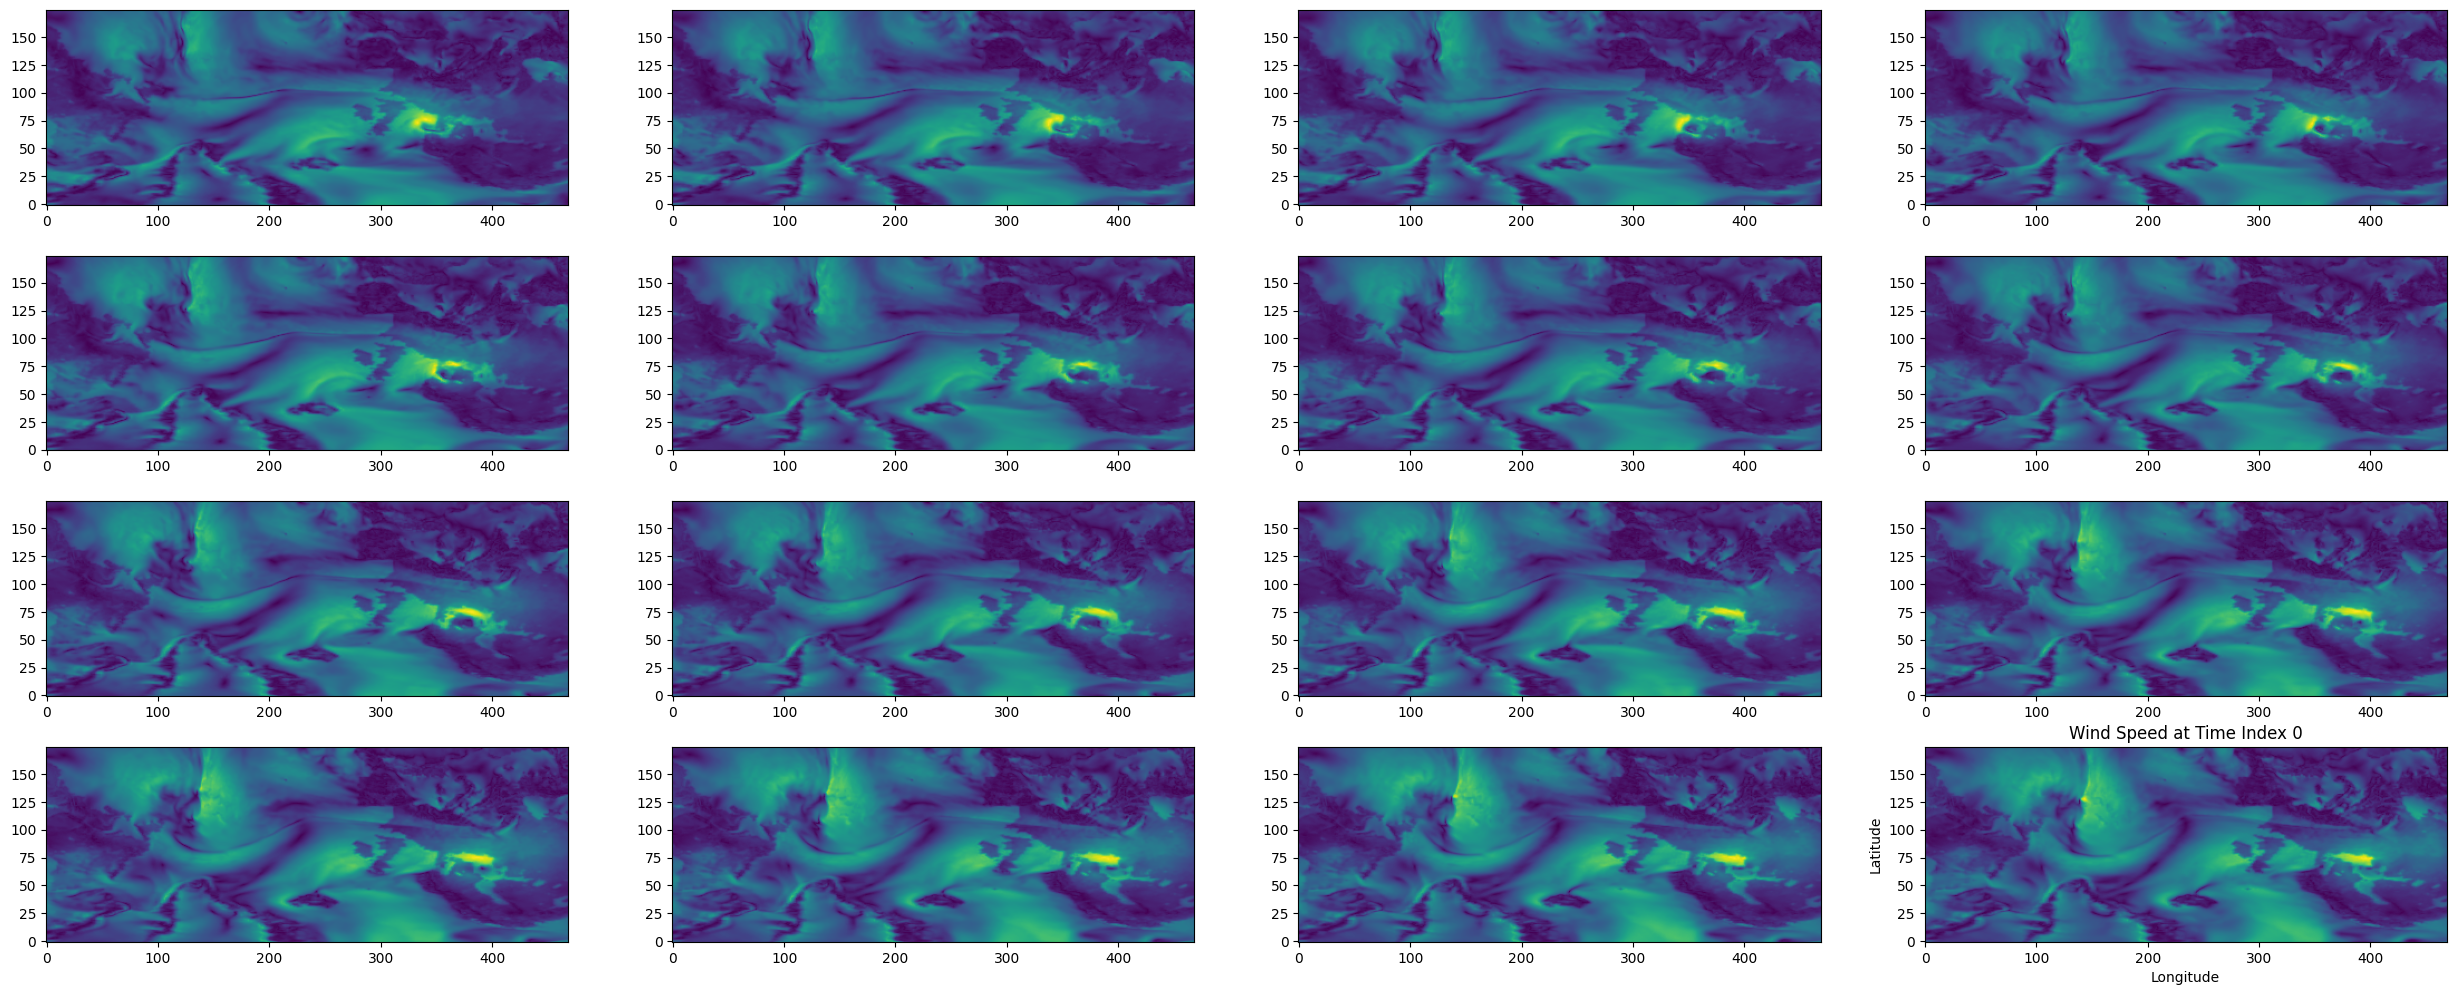

In [5]:
wind_speed = np.sqrt(data['u10']**2 + data['v10']**2)

#wind_speed_at_time = wind_speed.isel(valid_time = first_dec[0])
    
# Plot wind speed
fig, ax = plt.subplots(4,4, figsize=(25, 10))
axes = ax.flatten()
for i in range(16):
    wind_speed_at_time = wind_speed.isel(valid_time = i+63)
    axes[i].imshow(wind_speed_at_time, cmap='viridis', origin='lower')


plt.title("Wind Speed at Time Index 0")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


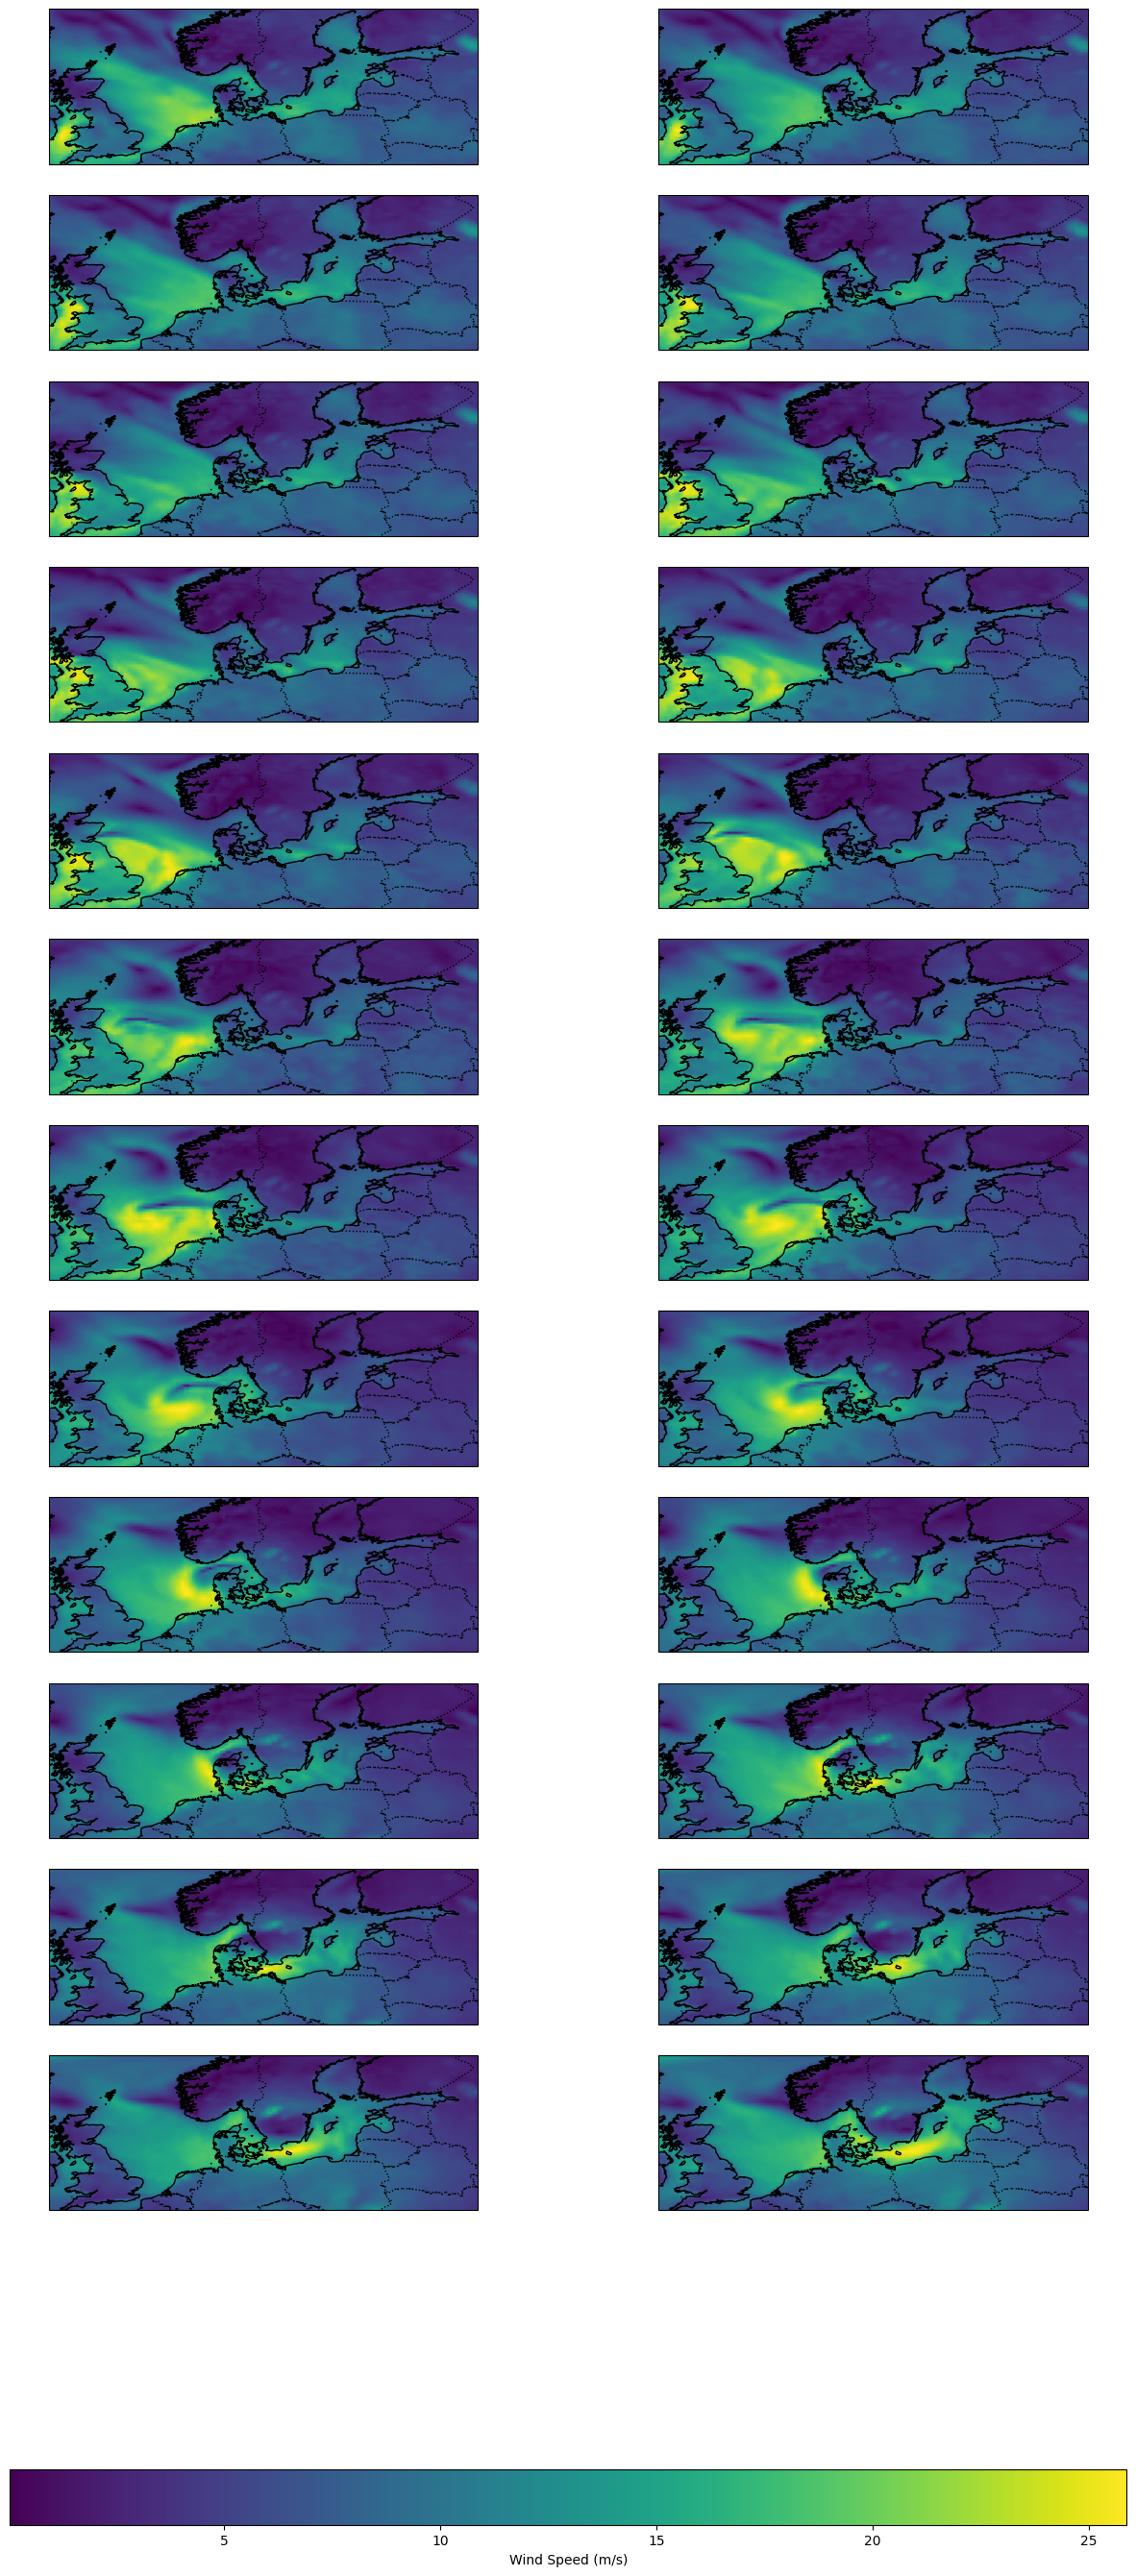

In [6]:
from cartopy import crs as ccrs, feature as cfeature
wind_speed = np.sqrt(data_storm_day['u10']**2 + data_storm_day['v10']**2)
pressure = data_storm_day['sp']

# Create a map projection
projection = ccrs.PlateCarree()

# Update the plotting code to include the map projection
fig, ax = plt.subplots(12, 2, figsize=(15, 35), subplot_kw={'projection': projection})
axes = ax.flatten()
for i in range(8*3):
    #windspeed_at_time = wind_speed.isel(valid_time=i+63)
    wind_speed_at_time = wind_speed.sel(valid_time=f'1999-12-03T{i}:00:00')  # Select the first time step
    im = axes[i].imshow(wind_speed_at_time, origin='upper',
                         extent=[data_storm_day.longitude.min().item(), data_storm_day.longitude.max().item(),
                                 data_storm_day.latitude.min().item(), data_storm_day.latitude.max().item()],
                         transform=ccrs.PlateCarree())
    axes[i].coastlines()
    axes[i].add_feature(cfeature.BORDERS, linestyle=':')
    axes[i].add_feature(cfeature.LAND, edgecolor='black')
    #axes[i].add_feature(cfeature.LAKES, edgecolor='black')
    #axes[i].add_feature(cfeature.RIVERS)

fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1, label='Wind Speed (m/s)')